# Mixed Distributions in QMCPy

A finite mixture combines several probability distributions into one overall distribution, with each component selected according to a specified probability. This is useful when a population or model naturally has multiple regimes or subgroups.

QMCPy provides TrueMeasures such as `Gaussian`, `Uniform`, and `SciPyWrapper` to transform uniform QMC points into samples from a target distribution. Before this addition, it had no general-purpose TrueMeasure for a finite mixture of component TrueMeasures.

For example, consider
$$
X\sim 0.3\,N(-2,0.7^2)+0.7\,N(2.5,1.1^2).
$$
Sampling either Gaussian alone is straightforward. Sampling this distribution hierarchically requires two operations: choose a component with its mixture probability, then apply that component's transform. **`Mixture` adds this missing hierarchical layer to the TrueMeasure framework.**

We first construct and sample this mixture through the public API. We then investigate how the selection step affects empirical QMC convergence, moving from simple functions to correlated Gaussian components and a nonlinear integrand.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMCSoftware/blob/develop/demos/mixed_distributions.ipynb)

In [1]:
# @title Execute this cell to install dependencies
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    !git clone -q --depth 1 --branch feature/mixed-distribution https://github.com/QMCSoftware/qmcpy.git /content/qmcpy
    !pip install -q -e /content/qmcpy

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from IPython.display import Markdown, display

from qmcpy import DigitalNetB2, Gaussian, Mixture

plt.style.use("seaborn-v0_8-whitegrid")


def show_table(headers, rows):
    """Render a compact table from the existing computed results."""
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    lines.extend("| " + " | ".join(map(str, row)) + " |" for row in rows)
    display(Markdown("\n".join(lines)))


## 1. What Mixture adds

A `Mixture` is built from three inputs:

- An outer discrete distribution that supplies uniform driver points.
- Compatible, direct component TrueMeasures with the same output dimension $d$.
- Positive component probabilities $p_j$ that sum to one.

The outer sampler has dimension $d+1$: one coordinate selects the component and the remaining $d$ coordinates enter its transform. The returned sample still has dimension $d$ because the selector is used internally. Thus a one-dimensional Gaussian mixture needs a two-dimensional outer `DigitalNetB2` sampler.

The existing component transforms are reused; the component samplers themselves are not drawn from. This gives users a single TrueMeasure representing the full mixture.


## 2. Hierarchical construction

Let $U\in[0,1]^d$ be the continuous uniform coordinates and $V\in[0,1]$ an independent uniform component selector. The transformation $S$ produces a reference random variable $Z=S(U)$; $T_1$ and $T_2$ map $Z$ into the two component distributions. If component 1 has probability $p$, the final mixture sample is
$$
X=\begin{cases}
T_1(Z), & V\le p,\\
T_2(Z), & V>p.
\end{cases}
$$
For more components, cumulative sums of the probabilities $p_j$ partition the selector interval. If $C(V)$ is the selected component index, the construction is $X=T_{C(V)}(Z)$.

For a function $f$ evaluated on the mixture sample, the induced unit-cube integrand is
$$
g(U,V)
=f(T_1(S(U)))\,\mathbf{1}_{\{V\le p\}}
+f(T_2(S(U)))\,\mathbf{1}_{\{V>p\}},
$$
where $\mathbf{1}$ is an indicator. For fixed $U$, crossing $V=p$ changes the selected transformation. Even if $f$, $S$, and the component transforms are smooth, $g$ may therefore jump in the $V$ direction.

The hierarchical construction has the intended mixture distribution. The selector boundary raises a numerical question about QMC convergence, not a question about validity; first, we show how to use the construction.


## 3. Constructing and sampling a Mixture

The following code builds the Gaussian mixture from the introduction, draws 4096 samples, and reports the driver dimension and returned shape. The Gaussian parameters `sigma1` and `sigma2` are standard deviations, so their squares are passed as covariances; the mixture weights remain $0.3$ and $0.7$.

`Mixture` uses the first outer coordinate as $V$ and the remaining coordinate for the selected Gaussian transform. At an exact cumulative boundary the API uses $V<p$, rather than the $V\le p$ convention above, with $V=1$ assigned to the final component. This changes only boundary assignments, not the distribution or expectation.


In [3]:
mu1, sigma1 = -2.0, 0.7
mu2, sigma2 = 2.5, 1.1
p = 0.3

components = [
    Gaussian(DigitalNetB2(1, seed=20260912), mean=mu1, covariance=sigma1**2),
    Gaussian(DigitalNetB2(1, seed=20260913), mean=mu2, covariance=sigma2**2),
]
mixture = Mixture(
    DigitalNetB2(2, seed=20260914),
    components,
    [p, 1 - p],
)
mixture_samples = mixture(4096)
samples = mixture_samples[:, 0]
expected_mean = p * mu1 + (1 - p) * mu2

show_table(
    ["Outer sampler dimension", "Returned sample shape"],
    [[mixture.discrete_distrib.d, str(mixture_samples.shape)]],
)


| Outer sampler dimension | Returned sample shape |
| --- | --- |
| 2 | (4096, 1) |

The outer sampler has dimension two, but the returned shape is $(4096,1)$: each point supplies one selector and one Gaussian-transform coordinate, and only the resulting one-dimensional observation is returned. To inspect the generated distribution, we next plot those same samples and compare their mean with $p\mu_1+(1-p)\mu_2$.


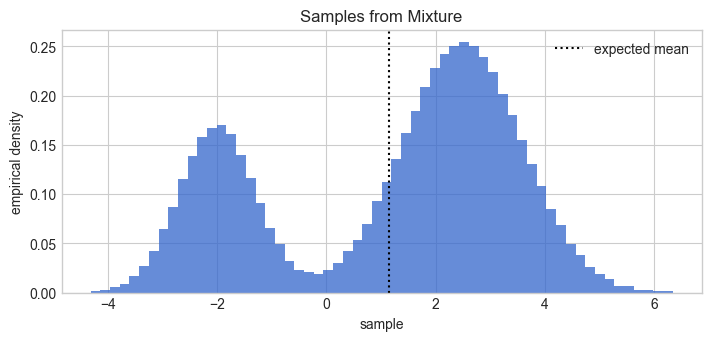

| Empirical sample mean | Theoretical mixture mean |
| --- | --- |
| 1.149730 | 1.150000 |

In [4]:
fig, ax = plt.subplots(figsize=(7.0, 3.3), layout="constrained")
ax.hist(samples, bins=60, density=True, color="#3366CC", alpha=0.75)
ax.axvline(expected_mean, color="black", linestyle=":", label="expected mean")
ax.set(xlabel="sample", ylabel="empirical density", title="Samples from Mixture")
ax.legend(frameon=False)
plt.show()

show_table(
    ["Empirical sample mean", "Theoretical mixture mean"],
    [[f"{samples.mean():.6f}", f"{expected_mean:.6f}"]],
)


The horizontal axis is the sampled value and the vertical axis is empirical density; the groups near $-2$ and $2.5$ reflect the two Gaussian components. The empirical mean is close to the theoretical mixture mean marked by the dotted line, providing a simple check of the public sampling example. This single sample set can now be used for downstream calculations.


## 4. Why the selector matters for QMC

The selector coordinate $V$ can introduce a discontinuity when the selected component changes. What empirical QMC convergence does the hierarchical construction show when estimating
$$
I=E[f(X)]=\int_{[0,1]^{d+1}}g(U,V)\,dU\,dV?
$$
$N$ denotes the total number of evaluations of $f$: each driver point $(U,V)$ produces one mixture sample $X$ and one value $f(X)$.

The controlled experiments use $(U,V)$ with $V$ last and explicit Gaussian maps $S,T_j$. The public API example uses the selector first; coordinate order and Gaussian factorization can affect QMC errors, so the curves characterize the stated hierarchical construction, not every API configuration.


## 5. Simple one-dimensional convergence examples

Start with $f(x)=x^2$ and $f(x)=\cos(x)$: both are smooth, but the second is bounded and oscillatory. For a Gaussian component $X\sim N(\mu,\sigma^2)$, exact expectations make their errors measurable without numerical reference integration:
$$
E[X^2]=\mu^2+\sigma^2,\qquad
E[\cos(X)]=e^{-\sigma^2/2}\cos(\mu).
$$
The exact mixture values are the probability-weighted component values. Here $S(U)=\Phi^{-1}(U)$, where $\Phi$ is the standard-normal CDF, and $T_1(Z)=-2+0.7Z$, $T_2(Z)=2.5+1.1Z$.

We use randomized DigitalNetB2 points at budgets $N=2^6,\ldots,2^{15}$. The $R=32$ randomizations are independent randomizations of the digital net, giving 32 estimates at each budget. If $\widehat I_{r,N}$ is the estimate in randomization $r$, we report
$$
\operatorname{RMSE}(N)
=\left[\frac{1}{R}\sum_{r=1}^{R}
(\widehat I_{r,N}-I_{\mathrm{exact}})^2\right]^{1/2}.
$$
The fitted slope is obtained by regressing $\log(\operatorname{RMSE})$ on $\log N$ over the largest five budgets. Both functions use the same Gaussian samples; the blue curves and table below show the hierarchical behavior.


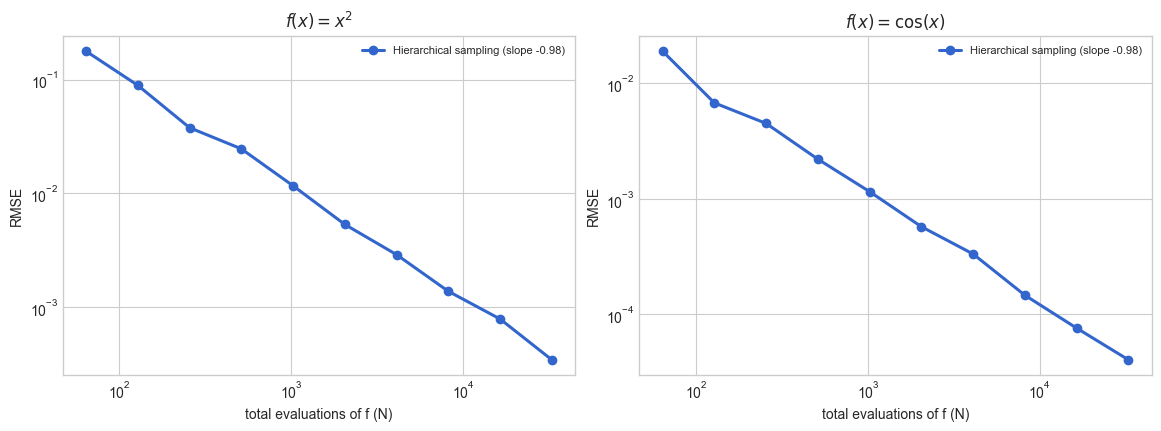

| Function | Exact expectation | Hierarchical slope | Final RMSE (N=32768) |
| --- | --- | --- | --- |
| $x^2$ | 6.569000000 | -0.98 | 0.000343876 |
| $\cos(x)$ | -0.403954834 | -0.98 | 4.00019e-05 |

In [5]:
sample_sizes = 2 ** np.arange(6, 16)
replications = 32
n_max = int(sample_sizes[-1])
exact = p * (mu1**2 + sigma1**2) + (1 - p) * (mu2**2 + sigma2**2)
exact_cos = (
    p * np.exp(-sigma1**2 / 2) * np.cos(mu1)
    + (1 - p) * np.exp(-sigma2**2 / 2) * np.cos(mu2)
)


def to_normal(u):
    lower = np.nextafter(0.0, 1.0)
    upper = np.nextafter(1.0, 0.0)
    return norm.ppf(np.clip(u, lower, upper))


# Hierarchical mixture sampling in the calculation. Columns are U and V, in that order.
points = DigitalNetB2(
    2, seed=20260922, replications=replications, randomize="LMS DS"
)(n_max)
z = to_normal(points[..., 0])
v = points[..., 1]
x = np.where(v <= p, mu1 + sigma1 * z, mu2 + sigma2 * z)
values_1d = x**2
values_1d_cos = np.cos(x)

rmse_1d = []
rmse_1d_cos = []
for n in sample_sizes:
    estimates_1d = values_1d[:, :n].mean(axis=1)
    rmse_1d.append(np.sqrt(np.mean((estimates_1d - exact) ** 2)))
    estimates_1d_cos = values_1d_cos[:, :n].mean(axis=1)
    rmse_1d_cos.append(
        np.sqrt(np.mean((estimates_1d_cos - exact_cos) ** 2))
    )

rmse_1d = np.asarray(rmse_1d)
rmse_1d_cos = np.asarray(rmse_1d_cos)
fit = slice(-5, None)
slope_1d = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse_1d[fit]), 1
)[0]
slope_1d_cos = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse_1d_cos[fit]), 1
)[0]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), layout="constrained")
for ax, errors, slope, title in [
    (axes[0], rmse_1d, slope_1d, r"$f(x)=x^2$"),
    (axes[1], rmse_1d_cos, slope_1d_cos, r"$f(x)=\cos(x)$"),
]:
    ax.loglog(
        sample_sizes, errors, "o-", color="#3366CC", linewidth=2.2,
        label=f"Hierarchical sampling (slope {slope:.2f})",
    )
    ax.set(xlabel="total evaluations of f (N)", ylabel="RMSE", title=title)
    ax.legend(frameon=False, fontsize=8)
plt.show()

show_table(
    ["Function", "Exact expectation", "Hierarchical slope", f"Final RMSE (N={n_max})"],
    [
        [r"$x^2$", f"{exact:.9f}", f"{slope_1d:.2f}",
         f"{rmse_1d[-1]:.6g}"],
        [r"$\cos(x)$", f"{exact_cos:.9f}", f"{slope_1d_cos:.2f}",
         f"{rmse_1d_cos[-1]:.6g}"],
    ],
)


Both blue RMSE curves fall approximately as $N^{-1}$ over the fitted range, with hierarchical slopes of about $-0.98$. On the log-log axes, this means that doubling the total evaluation budget roughly halves the observed error. The selector discontinuity does not force a slope near the usual $-1/2$ Monte Carlo benchmark in these examples.

This is an empirical finite-budget observation, not a theoretical convergence guarantee. The one-dimensional examples contain no dependence between output coordinates, so we next test correlated multivariate components.


## 6. Higher-dimensional correlated Gaussian mixture

To test whether the hierarchical behavior persists with dependence between coordinates, we use Gaussian components in $d=5$, then $d=10$. Random mean vectors $\mu_j$ and dense factors $A_j$, scaled by $1/\sqrt d$, define positive semidefinite, non-diagonal covariances $\Sigma_j=A_jA_j^\mathsf{T}$.

For one component, let $Z\sim N(0,I_d)$, where $I_d$ is the identity matrix, and $X=\mu+AZ$. With $f(x)=x^\mathsf{T}x$,
$$
\begin{aligned}
X^\mathsf{T}X
&=(\mu+AZ)^\mathsf{T}(\mu+AZ)\\
&=\mu^\mathsf{T}\mu+2\mu^\mathsf{T}AZ
  +Z^\mathsf{T}A^\mathsf{T}AZ.
\end{aligned}
$$
Since $E[Z]=0$, the cross term vanishes. Also, $E[ZZ^\mathsf{T}]=I_d$, so
$$
E[Z^\mathsf{T}A^\mathsf{T}AZ]
=\operatorname{tr}(A^\mathsf{T}A)
=\operatorname{tr}(AA^\mathsf{T})
=\operatorname{tr}(\Sigma).
$$
Consequently,
$$
E[X^\mathsf{T}X]=\mu^\mathsf{T}\mu+\operatorname{tr}(\Sigma),
$$
so for a finite mixture,
$$
I_{\mathrm{exact}}=E[X^\mathsf{T}X]
=\sum_j p_j\left[\mu_j^\mathsf{T}\mu_j+\operatorname{tr}(\Sigma_j)\right].
$$

The code uses row samples, `Z @ A.T + mu`, consistent with $\Sigma=AA^\mathsf{T}$. We check the formula in 5D at $p=0.3$ and for one fixed pair of 10D components at $p=0.3$ and $p=0.1$. Each independent million-sample ordinary Monte Carlo calculation is **only a sanity check of the analytical reference**, not a competing integration strategy. The table reports the analytical value, sample estimate, absolute difference, and estimated MC standard error.


In [6]:
d = 5
p5 = 0.3
rng5 = np.random.default_rng(123)
mu1_5d = rng5.standard_normal(d)
mu2_5d = rng5.standard_normal(d)
A1 = rng5.standard_normal((d, d)) / np.sqrt(d)
A2 = rng5.standard_normal((d, d)) / np.sqrt(d)
Sigma1 = A1 @ A1.T
Sigma2 = A2 @ A2.T
exact5 = (
    p5 * (mu1_5d @ mu1_5d + np.trace(Sigma1))
    + (1 - p5) * (mu2_5d @ mu2_5d + np.trace(Sigma2))
)

# Sanity check only: this ordinary random sample is not a curve in the QMC plot.
mc_rng5 = np.random.default_rng(456)
mc_n5 = 1_000_000
z_mc5 = mc_rng5.standard_normal((mc_n5, d))
choose1_mc5 = mc_rng5.random(mc_n5) < p5
x_mc5 = np.empty_like(z_mc5)
x_mc5[choose1_mc5] = z_mc5[choose1_mc5] @ A1.T + mu1_5d
x_mc5[~choose1_mc5] = z_mc5[~choose1_mc5] @ A2.T + mu2_5d
values_mc5 = np.sum(x_mc5**2, axis=-1)
mc_mean5 = values_mc5.mean()
mc_se5 = values_mc5.std(ddof=1) / np.sqrt(mc_n5)


In [7]:
d10 = 10
p10 = 0.3
rng10 = np.random.default_rng(321)
mu1_10d = rng10.standard_normal(d10)
mu2_10d = rng10.standard_normal(d10)
A1_10 = rng10.standard_normal((d10, d10)) / np.sqrt(d10)
A2_10 = rng10.standard_normal((d10, d10)) / np.sqrt(d10)
Sigma1_10 = A1_10 @ A1_10.T
Sigma2_10 = A2_10 @ A2_10.T
exact10 = (
    p10 * (mu1_10d @ mu1_10d + np.trace(Sigma1_10))
    + (1 - p10) * (mu2_10d @ mu2_10d + np.trace(Sigma2_10))
)

# Ordinary Monte Carlo checks only the analytical expectation.
mc_rng10 = np.random.default_rng(654)
mc_n10 = 1_000_000
z_mc10 = mc_rng10.standard_normal((mc_n10, d10))
choose1_mc10 = mc_rng10.random(mc_n10) < p10
x_mc10 = np.empty_like(z_mc10)
x_mc10[choose1_mc10] = z_mc10[choose1_mc10] @ A1_10.T + mu1_10d
x_mc10[~choose1_mc10] = z_mc10[~choose1_mc10] @ A2_10.T + mu2_10d
values_mc10 = np.sum(x_mc10**2, axis=-1)
mc_mean10 = values_mc10.mean()
mc_se10 = values_mc10.std(ddof=1) / np.sqrt(mc_n10)

off_diagonal10 = ~np.eye(d10, dtype=bool)


In [8]:
p10_imbalanced = 0.1
exact10_imbalanced = (
    p10_imbalanced * (mu1_10d @ mu1_10d + np.trace(Sigma1_10))
    + (1 - p10_imbalanced) * (mu2_10d @ mu2_10d + np.trace(Sigma2_10))
)

# Sanity check only: reuse the component parameters, not the QMC points.
mc_rng10_imbalanced = np.random.default_rng(754)
mc_n10_imbalanced = 1_000_000
z_mc10_imbalanced = mc_rng10_imbalanced.standard_normal((mc_n10_imbalanced, d10))
choose1_mc10_imbalanced = (
    mc_rng10_imbalanced.random(mc_n10_imbalanced) < p10_imbalanced
)
x_mc10_imbalanced = np.empty_like(z_mc10_imbalanced)
x_mc10_imbalanced[choose1_mc10_imbalanced] = (
    z_mc10_imbalanced[choose1_mc10_imbalanced] @ A1_10.T + mu1_10d
)
x_mc10_imbalanced[~choose1_mc10_imbalanced] = (
    z_mc10_imbalanced[~choose1_mc10_imbalanced] @ A2_10.T + mu2_10d
)
values_mc10_imbalanced = np.sum(x_mc10_imbalanced**2, axis=-1)
mc_mean10_imbalanced = values_mc10_imbalanced.mean()
mc_se10_imbalanced = (
    values_mc10_imbalanced.std(ddof=1) / np.sqrt(mc_n10_imbalanced)
)


In [9]:
# Present the three existing validation cases together.
validation_rows = []
for dimension, probability, covariances, reference, mc_mean, mc_se in [
    (d, p5, (Sigma1, Sigma2), exact5, mc_mean5, mc_se5),
    (d10, p10, (Sigma1_10, Sigma2_10), exact10, mc_mean10, mc_se10),
    (d10, p10_imbalanced, (Sigma1_10, Sigma2_10),
     exact10_imbalanced, mc_mean10_imbalanced, mc_se10_imbalanced),
]:
    off_diagonal = ~np.eye(dimension, dtype=bool)
    dense = all(np.all(cov[off_diagonal] != 0) for cov in covariances)
    validation_rows.append([
        dimension, probability, "Dense/non-diagonal" if dense else "Check covariance",
        f"{reference:.9f}", f"{mc_mean:.9f}",
        f"{abs(mc_mean - reference):.9f}", f"{mc_se:.9f}",
    ])
show_table(
    ["d", "p", "Covariances", "Analytical value", "MC check",
     "Absolute difference", "MC standard error"],
    validation_rows,
)


| d | p | Covariances | Analytical value | MC check | Absolute difference | MC standard error |
| --- | --- | --- | --- | --- | --- | --- |
| 5 | 0.3 | Dense/non-diagonal | 6.565568616 | 6.574820424 | 0.009251808 | 0.005233175 |
| 10 | 0.3 | Dense/non-diagonal | 12.595533665 | 12.595350591 | 0.000183074 | 0.008379353 |
| 10 | 0.1 | Dense/non-diagonal | 10.450854779 | 10.454013577 | 0.003158797 | 0.006753699 |

All three absolute discrepancies are below two estimated MC standard errors, consistent with ordinary sampling error and supporting the analytical references used for RMSE. The covariance summary confirms that these are non-diagonal examples, rather than repeated independent one-dimensional components.


## 7. Hierarchical convergence in higher dimensions

Does the hierarchical estimator still improve systematically when the components are correlated and multidimensional? We reuse the budgets, 32 randomizations, and fitting rule from Section 5, now applying $S$ coordinatewise and $T_j(Z)=\mu_j+A_jZ$.

The 5D case tests correlation, and the 10D case tests a different, higher-dimensional component pair. A final panel keeps those 10D components but changes $p$ to $0.1$. The two fixed 10D runs use different QMC randomizations; their difference should not be attributed solely to the probability change. Look for the blue RMSE trend and its fitted slope in each panel.


In [10]:
# Hierarchical mixture sampling: d normal inputs followed by one decision coordinate.
points5 = DigitalNetB2(
    d + 1, seed=124, replications=replications, randomize="LMS DS"
)(n_max)
# to_normal clips away from 0 and 1 with np.nextafter before norm.ppf.
z5 = to_normal(points5[..., :d])
choose1_5 = points5[..., -1] < p5
x5 = np.empty_like(z5)
x5[choose1_5] = z5[choose1_5] @ A1.T + mu1_5d
x5[~choose1_5] = z5[~choose1_5] @ A2.T + mu2_5d
values5 = np.sum(x5**2, axis=-1)

rmse5 = []
for n in sample_sizes:
    estimates5 = values5[:, :n].mean(axis=1)
    rmse5.append(
        np.sqrt(np.mean((estimates5 - exact5) ** 2))
    )

rmse5 = np.asarray(rmse5)
slope5 = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse5[fit]), 1
)[0]


In [11]:
# Hierarchical mixture sampling: ten normal inputs followed by one decision coordinate.
points10 = DigitalNetB2(
    d10 + 1, seed=322, replications=replications, randomize="LMS DS"
)(n_max)
# Reuse the safe clipping before norm.ppf; row samples use Z @ A.T + mu.
z10 = to_normal(points10[..., :d10])
choose1_10 = points10[..., -1] < p10
x10 = np.empty_like(z10)
x10[choose1_10] = z10[choose1_10] @ A1_10.T + mu1_10d
x10[~choose1_10] = z10[~choose1_10] @ A2_10.T + mu2_10d
values10 = np.sum(x10**2, axis=-1)

rmse10 = []
for n in sample_sizes:
    estimates10 = values10[:, :n].mean(axis=1)
    rmse10.append(
        np.sqrt(np.mean((estimates10 - exact10) ** 2))
    )

rmse10 = np.asarray(rmse10)
slope10 = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse10[fit]), 1
)[0]


In [12]:
# Hierarchical mixture sampling: reuse the 10D transforms with a new selector threshold and QMC seed.
points10_imbalanced = DigitalNetB2(
    d10 + 1, seed=422, replications=replications, randomize="LMS DS"
)(n_max)
z10_imbalanced = to_normal(points10_imbalanced[..., :d10])
choose1_10_imbalanced = points10_imbalanced[..., -1] < p10_imbalanced
x10_imbalanced = np.empty_like(z10_imbalanced)
x10_imbalanced[choose1_10_imbalanced] = (
    z10_imbalanced[choose1_10_imbalanced] @ A1_10.T + mu1_10d
)
x10_imbalanced[~choose1_10_imbalanced] = (
    z10_imbalanced[~choose1_10_imbalanced] @ A2_10.T + mu2_10d
)
values10_imbalanced = np.sum(x10_imbalanced**2, axis=-1)

rmse10_imbalanced = []
for n in sample_sizes:
    estimates10_imbalanced = values10_imbalanced[:, :n].mean(axis=1)
    rmse10_imbalanced.append(
        np.sqrt(np.mean((estimates10_imbalanced - exact10_imbalanced) ** 2))
    )

rmse10_imbalanced = np.asarray(rmse10_imbalanced)
slope10_imbalanced = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse10_imbalanced[fit]), 1
)[0]


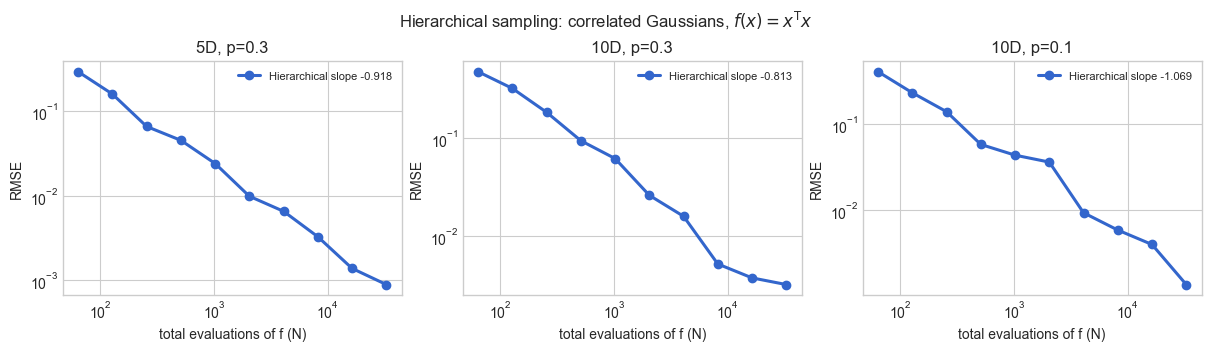

| Case | Hierarchical slope | Final RMSE (N=32768) |
| --- | --- | --- |
| 5D, p=0.3 | -0.918 | 0.000890547877 |
| 10D, p=0.3 | -0.813 | 0.00321166253 |
| 10D, p=0.1 | -1.069 | 0.00137168872 |

In [13]:
fixed_cases = [
    ("5D, p=0.3", rmse5, slope5),
    ("10D, p=0.3", rmse10, slope10),
    ("10D, p=0.1", rmse10_imbalanced, slope10_imbalanced),
]
fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.4), layout="constrained")
for ax, (case, errors, slope) in zip(axes, fixed_cases):
    ax.loglog(
        sample_sizes, errors, "o-", color="#3366CC", linewidth=2.2,
        label=f"Hierarchical slope {slope:.3f}",
    )
    ax.set(xlabel="total evaluations of f (N)", ylabel="RMSE", title=case)
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(r"Hierarchical sampling: correlated Gaussians, $f(x)=x^\mathsf{T}x$")
plt.show()

show_table(
    ["Case", "Hierarchical slope", f"Final RMSE (N={n_max})"],
    [
        [case, f"{slope:.3f}", f"{errors[-1]:.9g}"]
        for case, errors, slope in fixed_cases
    ],
)


The blue curves show decreasing RMSE with total evaluations $N$, but not one common slope: the hierarchical fits are $-0.918$ in 5D, $-0.813$ in 10D at $p=0.3$, and $-1.069$ in 10D at $p=0.1$. These fixed cases demonstrate variation with the chosen dimension and component structure, not an isolated causal effect of dimension or probability. To assess whether one selected covariance structure is representative, we next summarize many mixtures.


## 8. Robustness across random mixtures

Is the hierarchical convergence in one chosen covariance structure representative? A single mixture could be unusually easy or difficult, so we repeat the quadratic experiment across 100 independently generated pairs of correlated 10D Gaussian components.

Each case uses standard-normal mean vectors and dense factors scaled by $1/\sqrt{10}$. The same components and randomized QMC point sets are reused at $p=0.3$ and $p=0.1$, with the budgets and 32 randomizations from Section 5. Fixed seeds reproduce the cases; processing them one at a time limits memory use.

The blue line shows median hierarchical RMSE versus total evaluations $N$. Its shaded region is the **25th–75th percentile across random mixture instances, not a confidence interval**. The table summarizes the distribution of individual hierarchical slope fits, rather than fitting a slope to the median curve.


In [14]:
from time import perf_counter


def random_mixture_rmse(case_seed, budgets, n_rep, probabilities):
    """Return hierarchical RMSE curves indexed by probability and budget."""
    d_case = 10
    parameter_seed, qmc_seed = case_seed.spawn(2)
    rng_case = np.random.default_rng(parameter_seed)
    mean1 = rng_case.standard_normal(d_case)
    mean2 = rng_case.standard_normal(d_case)
    factor1 = rng_case.standard_normal((d_case, d_case)) / np.sqrt(d_case)
    factor2 = rng_case.standard_normal((d_case, d_case)) / np.sqrt(d_case)
    covariance1 = factor1 @ factor1.T
    covariance2 = factor2 @ factor2.T
    moment1 = mean1 @ mean1 + np.trace(covariance1)
    moment2 = mean2 @ mean2 + np.trace(covariance2)
    max_budget = int(budgets[-1])

    # Generate once per case: both probabilities use exactly these U and V.
    points_case = DigitalNetB2(
        d_case + 1, seed=qmc_seed, replications=n_rep, randomize="LMS DS"
    )(max_budget)
    normals = to_normal(points_case[..., :d_case])
    selector = points_case[..., -1].copy()
    del points_case

    curves = np.empty((len(probabilities), len(budgets)))
    for probability_index, probability in enumerate(probabilities):
        exact_case = probability * moment1 + (1 - probability) * moment2
        choose1 = selector < probability
        values = np.empty(selector.shape)
        values[choose1] = np.sum(
            (normals[choose1] @ factor1.T + mean1) ** 2, axis=-1
        )
        values[~choose1] = np.sum(
            (normals[~choose1] @ factor2.T + mean2) ** 2, axis=-1
        )
        estimates = np.stack(
            [values[:, :n].mean(axis=1) for n in budgets], axis=1
        )
        curves[probability_index] = np.sqrt(
            np.mean((estimates - exact_case) ** 2, axis=0)
        )
    return curves


In [15]:
n_cases100 = 100
d100 = 10
p_values100 = [0.3, 0.1]
master_seed100 = 20260925
case_seeds100 = np.random.SeedSequence(master_seed100).spawn(n_cases100)

# Axes: random case, probability, sample budget.
rmse_cases100 = np.empty((n_cases100, len(p_values100), len(sample_sizes)))
slopes_cases100 = np.empty((n_cases100, len(p_values100)))
started100 = perf_counter()
for case_index100, case_seed100 in enumerate(case_seeds100):
    curves100 = random_mixture_rmse(
        case_seed100, sample_sizes, replications, p_values100
    )
    rmse_cases100[case_index100] = curves100
    for probability_index100 in range(len(p_values100)):
        slopes_cases100[case_index100, probability_index100] = np.polyfit(
            np.log(sample_sizes[fit]),
            np.log(curves100[probability_index100, fit]),
            1,
        )[0]
elapsed100 = perf_counter() - started100


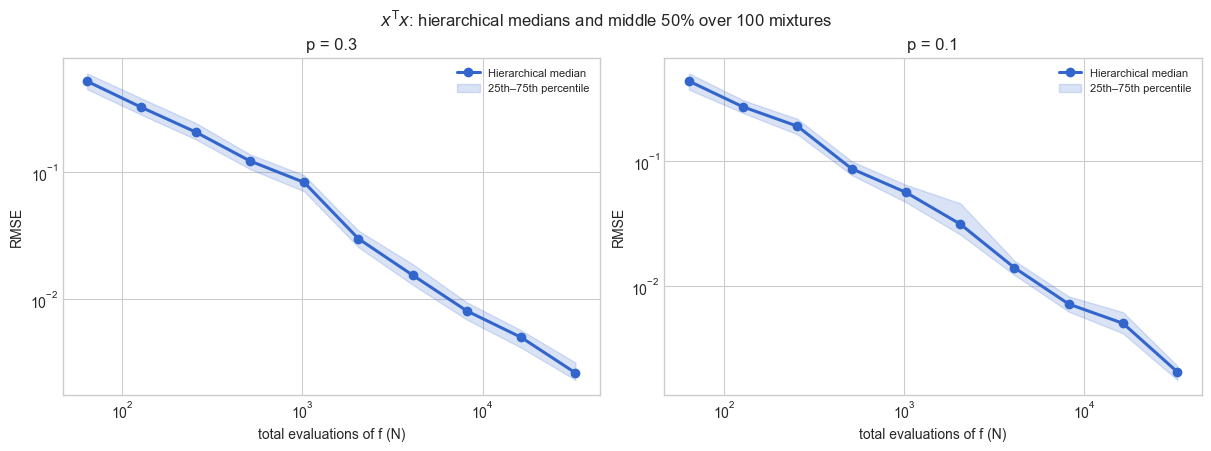

| p | Hierarchical median slope | 25%–75% slope | Median final RMSE (N=32768) |
| --- | --- | --- | --- |
| 0.3 | -0.875 | [-0.928, -0.797] | 0.00262255 |
| 0.1 | -0.956 | [-1.023, -0.887] | 0.00202802 |

In [16]:
rmse_quantiles100 = np.quantile(rmse_cases100, [0.25, 0.5, 0.75], axis=0)
slope_quantiles100 = np.quantile(slopes_cases100, [0.25, 0.5, 0.75], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4), layout="constrained")
for probability_index100, (ax, probability100) in enumerate(zip(axes, p_values100)):
    lower100, median100, upper100 = rmse_quantiles100[:, probability_index100]
    ax.loglog(
        sample_sizes, median100, "o-", color="#3366CC", linewidth=2.2,
        label="Hierarchical median",
    )
    ax.fill_between(
        sample_sizes, lower100, upper100, color="#3366CC", alpha=0.18,
        label="25th–75th percentile",
    )
    ax.set(xlabel="total evaluations of f (N)", ylabel="RMSE", title=f"p = {probability100}")
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(r"$x^\mathsf{T}x$: hierarchical medians and middle 50% over 100 mixtures")
plt.show()

quadratic_rows = []
for probability_index100, probability100 in enumerate(p_values100):
    q25, median_slope, q75 = slope_quantiles100[:, probability_index100]
    median_final = rmse_quantiles100[1, probability_index100, -1]
    quadratic_rows.append([
        probability100, f"{median_slope:.3f}",
        f"[{q25:.3f}, {q75:.3f}]", f"{median_final:.6g}",
    ])
show_table(
    ["p", "Hierarchical median slope", "25%–75% slope",
     f"Median final RMSE (N={n_max})"],
    quadratic_rows,
)


The blue median curves continue to fall over the tested budgets, with hierarchical median slopes of $-0.875$ at $p=0.3$ and $-0.956$ at $p=0.1$. The bands and slope quartiles show the variation that a single fixed example misses. Slopes near $-1$ are representative for this population and quadratic integrand, but this does not establish a rate for other functions; we next change only the integrand.


## 9. Dependence on the integrand

The preceding experiments use a quadratic integrand. To determine whether the observed hierarchical convergence depends on the integrand as well as the mixture transform, we keep the construction fixed and use $f(x)=\cos(x^\mathsf{T}x)$: a smooth, bounded, oscillatory function.

### Analytical reference and fixed-case check

First reuse the fixed 10D mixture at $p=0.3$. Measuring RMSE requires an accurate expectation, which is supplied by the characteristic function of the Gaussian quadratic form at frequency one:
$$
E[e^{iX^\mathsf{T}X}]
=\det(I_d-2i\Sigma)^{-1/2}
\exp\!\left(i\mu^\mathsf{T}(I_d-2i\Sigma)^{-1}\mu\right),
$$
where $i^2=-1$. Taking its real part gives
$$
E[\cos(X^\mathsf{T}X)]
=\operatorname{Re}\!\left(E[e^{iX^\mathsf{T}X}]\right).
$$
The exact mixture expectation is the probability-weighted sum of the exact Gaussian component expectations.

The helper diagonalizes the covariance and rotates the mean into its eigenbasis. It evaluates individual complex logarithms and scalar divisions, avoiding an explicit matrix inverse and an ambiguous square root of the combined determinant. This follows the square-root branch continuously from frequency zero. An independent million-sample Monte Carlo check stops execution if the discrepancy exceeds five estimated standard errors.


In [17]:
def gaussian_cos_squared_norm(mean, covariance):
    """Evaluate E[cos(X.T @ X)] using covariance eigenvalues."""
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    rotated_mean = eigenvectors.T @ mean
    factors = 1 - 2j * eigenvalues
    log_characteristic = (
        -0.5 * np.sum(np.log1p(-2j * eigenvalues))
        + 1j * np.sum(rotated_mean**2 / factors)
    )
    return np.exp(log_characteristic).real


p_cos10 = 0.3
exact_cos_component1 = gaussian_cos_squared_norm(mu1_10d, Sigma1_10)
exact_cos_component2 = gaussian_cos_squared_norm(mu2_10d, Sigma2_10)
exact_cos_mixture = (
    p_cos10 * exact_cos_component1 + (1 - p_cos10) * exact_cos_component2
)

# Independent ordinary Monte Carlo check; no new component parameters.
mc_rng_cos10 = np.random.default_rng(854)
mc_n_cos10 = 1_000_000
z_mc_cos10 = mc_rng_cos10.standard_normal((mc_n_cos10, d10))
choose1_mc_cos10 = mc_rng_cos10.random(mc_n_cos10) < p_cos10
x_mc_cos10 = np.empty_like(z_mc_cos10)
x_mc_cos10[choose1_mc_cos10] = (
    z_mc_cos10[choose1_mc_cos10] @ A1_10.T + mu1_10d
)
x_mc_cos10[~choose1_mc_cos10] = (
    z_mc_cos10[~choose1_mc_cos10] @ A2_10.T + mu2_10d
)
values_mc_cos10 = np.cos(np.sum(x_mc_cos10**2, axis=-1))
mc_mean_cos10 = values_mc_cos10.mean()
mc_se_cos10 = values_mc_cos10.std(ddof=1) / np.sqrt(mc_n_cos10)
mc_difference_cos10 = abs(mc_mean_cos10 - exact_cos_mixture)

if mc_difference_cos10 > 5 * mc_se_cos10:
    raise RuntimeError(
        "Analytical reference and Monte Carlo check disagree by more than "
        "five standard errors; investigate before computing QMC errors."
    )

show_table(
    ["Exact mixture expectation", "MC check", "Absolute difference", "MC standard error"],
    [[f"{exact_cos_mixture:.9f}", f"{mc_mean_cos10:.9f}",
      f"{mc_difference_cos10:.9f}", f"{mc_se_cos10:.9f}"]],
)


| Exact mixture expectation | MC check | Absolute difference | MC standard error |
| --- | --- | --- | --- |
| -0.003952653 | -0.004076803 | 0.000124151 | 0.000708177 |

The analytical reference and MC estimate differ by only 0.18 estimated standard errors, supporting the reference used to measure error. The next plot evaluates the cosine on exactly the same fixed 10D Gaussian samples and QMC points as Section 7, so the hierarchical transform and selector boundary are unchanged.


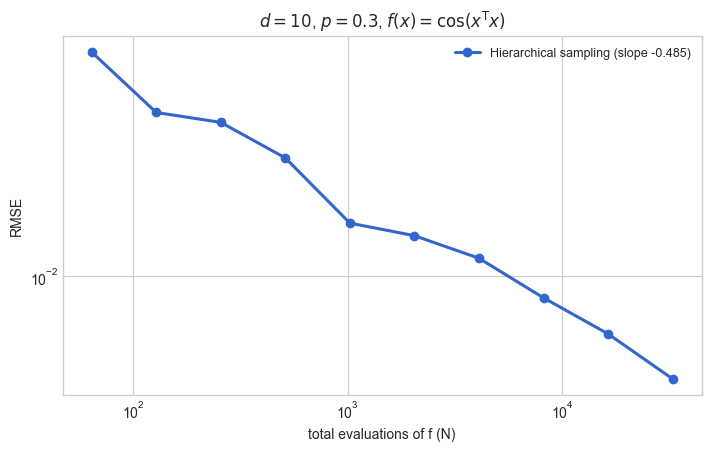

| Hierarchical slope | Final RMSE (N=32768) |
| --- | --- |
| -0.485 | 0.00383883802 |

In [18]:
values_cos10 = np.cos(np.sum(x10**2, axis=-1))

rmse_cos10 = []
for n in sample_sizes:
    estimates_cos10 = values_cos10[:, :n].mean(axis=1)
    rmse_cos10.append(
        np.sqrt(np.mean((estimates_cos10 - exact_cos_mixture) ** 2))
    )

rmse_cos10 = np.asarray(rmse_cos10)
slope_cos10 = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse_cos10[fit]), 1
)[0]

fig, ax = plt.subplots(figsize=(7.0, 4.4), layout="constrained")
ax.loglog(
    sample_sizes, rmse_cos10, "o-", color="#3366CC", linewidth=2.2,
    label=f"Hierarchical sampling (slope {slope_cos10:.3f})",
)
ax.set(
    xlabel="total evaluations of f (N)", ylabel="RMSE",
    title=r"$d=10$, $p=0.3$, $f(x)=\cos(x^\mathsf{T}x)$",
)
ax.legend(frameon=False, fontsize=9)
plt.show()

show_table(
    ["Hierarchical slope", f"Final RMSE (N={n_max})"],
    [[f"{slope_cos10:.3f}", f"{rmse_cos10[-1]:.9g}"]],
)


The blue RMSE curve has a fitted hierarchical slope of $-0.485$, much shallower than the quadratic slope of $-0.813$ on these same samples. Error still decreases with total evaluations, but the near-$-1$ behavior of the simple examples does not persist here. We repeat this change of integrand across the existing 100 mixtures to see whether the fixed case is representative.


### Same 100 mixtures with $\cos(x^\mathsf{T}x)$

Only $f$ changes from the Section 8 study: the 100 component pairs, their QMC point sets, both probabilities, and all 32 randomizations are reused. The validated analytical helper supplies each component's exact expectation, with no new Monte Carlo experiments.

As before, blue curves show median hierarchical RMSE against total evaluations, with 25th–75th percentile bands across mixtures. The slope quartiles below describe the variation among the 100 individual fits.


In [19]:
def replay_case_seed(case_seed):
    """Replay a case from child zero without advancing the Section 8 seed."""
    return np.random.SeedSequence(
        case_seed.entropy,
        spawn_key=case_seed.spawn_key,
        pool_size=case_seed.pool_size,
    )


def random_cos_mixture_rmse(case_seed, budgets, n_rep, probabilities):
    """Return hierarchical cosine RMSE curves: probability, budget."""
    d_case = 10
    parameter_seed, qmc_seed = replay_case_seed(case_seed).spawn(2)
    rng_case = np.random.default_rng(parameter_seed)
    mean1 = rng_case.standard_normal(d_case)
    mean2 = rng_case.standard_normal(d_case)
    factor1 = rng_case.standard_normal((d_case, d_case)) / np.sqrt(d_case)
    factor2 = rng_case.standard_normal((d_case, d_case)) / np.sqrt(d_case)
    covariance1 = factor1 @ factor1.T
    covariance2 = factor2 @ factor2.T
    exact1 = gaussian_cos_squared_norm(mean1, covariance1)
    exact2 = gaussian_cos_squared_norm(mean2, covariance2)
    max_budget = int(budgets[-1])

    # Same first ten U coordinates and final V coordinate as Section 8.
    points_case = DigitalNetB2(
        d_case + 1, seed=qmc_seed, replications=n_rep, randomize="LMS DS"
    )(max_budget)
    normals = to_normal(points_case[..., :d_case])
    selector = points_case[..., -1].copy()
    del points_case

    curves = np.empty((len(probabilities), len(budgets)))
    for probability_index, probability in enumerate(probabilities):
        exact_mix = probability * exact1 + (1 - probability) * exact2
        choose1 = selector < probability
        values = np.empty(selector.shape)
        values[choose1] = np.cos(np.sum(
            (normals[choose1] @ factor1.T + mean1) ** 2, axis=-1
        ))
        values[~choose1] = np.cos(np.sum(
            (normals[~choose1] @ factor2.T + mean2) ** 2, axis=-1
        ))
        estimates = np.stack(
            [values[:, :n].mean(axis=1) for n in budgets], axis=1
        )
        curves[probability_index] = np.sqrt(
            np.mean((estimates - exact_mix) ** 2, axis=0)
        )
    return curves


In [20]:
# Same axes as Section 8: case, probability, budget.
rmse_cos_cases100 = np.empty_like(rmse_cases100)
slopes_cos_cases100 = np.empty_like(slopes_cases100)
started_cos100 = perf_counter()
for case_index_cos100, case_seed_cos100 in enumerate(case_seeds100):
    curves_cos100 = random_cos_mixture_rmse(
        case_seed_cos100, sample_sizes, replications, p_values100
    )
    rmse_cos_cases100[case_index_cos100] = curves_cos100
    for probability_index_cos100 in range(len(p_values100)):
        slopes_cos_cases100[
            case_index_cos100, probability_index_cos100
        ] = np.polyfit(
            np.log(sample_sizes[fit]),
            np.log(curves_cos100[probability_index_cos100, fit]),
            1,
        )[0]
elapsed_cos100 = perf_counter() - started_cos100


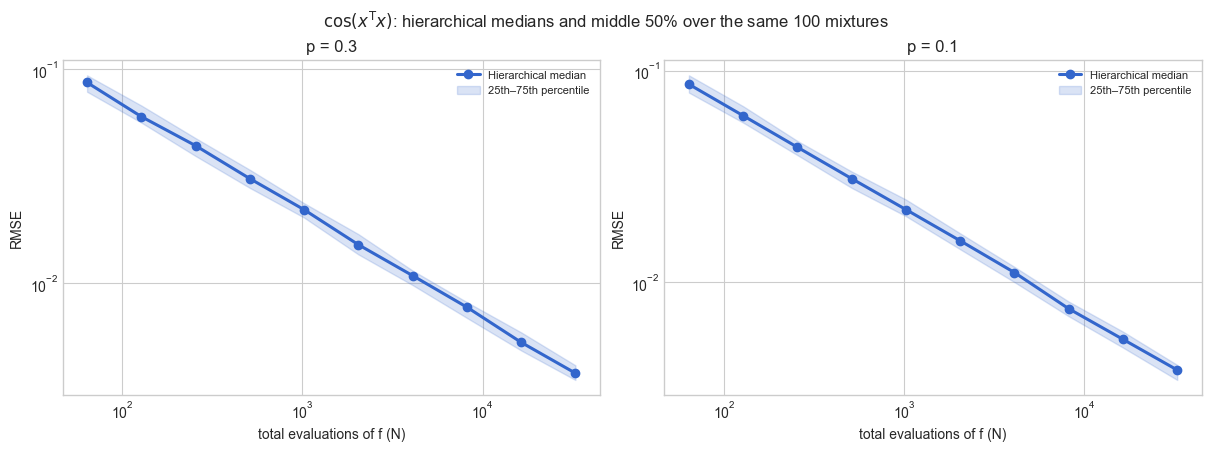

| p | Hierarchical median slope | 25%–75% slope | Median final RMSE (N=32768) |
| --- | --- | --- | --- |
| 0.3 | -0.493 | [-0.543, -0.457] | 0.00380472 |
| 0.1 | -0.511 | [-0.552, -0.470] | 0.00381571 |

In [21]:
rmse_quantiles_cos100 = np.quantile(rmse_cos_cases100, [0.25, 0.5, 0.75], axis=0)
slope_quantiles_cos100 = np.quantile(slopes_cos_cases100, [0.25, 0.5, 0.75], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4), layout="constrained")
for ip_cos100, (ax, p_cos100) in enumerate(zip(axes, p_values100)):
    lower_cos100, median_cos100, upper_cos100 = rmse_quantiles_cos100[:, ip_cos100]
    ax.loglog(
        sample_sizes, median_cos100, "o-", color="#3366CC", linewidth=2.2,
        label="Hierarchical median",
    )
    ax.fill_between(
        sample_sizes, lower_cos100, upper_cos100, color="#3366CC", alpha=0.18,
        label="25th–75th percentile",
    )
    ax.set(xlabel="total evaluations of f (N)", ylabel="RMSE", title=f"p = {p_cos100}")
    ax.legend(frameon=False, fontsize=8)
fig.suptitle(r"$\cos(x^\mathsf{T}x)$: hierarchical medians and middle 50% over the same 100 mixtures")
plt.show()

nonlinear_rows = []
for ip_cos100, p_cos100 in enumerate(p_values100):
    q25_cos, median_slope_cos, q75_cos = slope_quantiles_cos100[:, ip_cos100]
    median_final_cos = rmse_quantiles_cos100[1, ip_cos100, -1]
    nonlinear_rows.append([
        p_cos100, f"{median_slope_cos:.3f}",
        f"[{q25_cos:.3f}, {q75_cos:.3f}]", f"{median_final_cos:.6g}",
    ])
show_table(
    ["p", "Hierarchical median slope", "25%–75% slope",
     f"Median final RMSE (N={n_max})"],
    nonlinear_rows,
)


The hierarchical median slopes are $-0.493$ and $-0.511$: behavior near $-1/2$ is typical for this nonlinear integrand over the tested budgets, not just a peculiarity of the fixed example. The blue bands describe variation across mixtures, not uncertainty intervals for a theoretical rate.

### What changes when only the integrand changes?

The compact summary below compares hierarchical median slopes on the same mixtures and QMC points. It compares convergence behavior, not absolute RMSE values of differently scaled integrands.


In [22]:
show_table(
    ["p", r"Hierarchical median slope: $x^\mathsf{T}x$",
     r"Hierarchical median slope: $\cos(x^\mathsf{T}x)$"],
    [
        [probability, f"{slope_quantiles100[1, ip]:.3f}",
         f"{slope_quantiles_cos100[1, ip]:.3f}"]
        for ip, probability in enumerate(p_values100)
    ],
)


| p | Hierarchical median slope: $x^\mathsf{T}x$ | Hierarchical median slope: $\cos(x^\mathsf{T}x)$ |
| --- | --- | --- |
| 0.3 | -0.875 | -0.493 |
| 0.1 | -0.956 | -0.511 |

For both probabilities, changing from $x^\mathsf{T}x$ to $\cos(x^\mathsf{T}x)$ moves the hierarchical median slope from near $-1$ toward $-1/2$. This change is larger than the observed difference between the two probabilities. The selector boundary is unchanged: its presence alone does not determine the observed convergence, and the interaction between the mixture transform and $f$ matters.


## 10. Practical value of Mixture

`Mixture` returns samples from the full target distribution through the TrueMeasure interface. A single sample set can be used to visualize the mixture, inspect its empirical distribution, evaluate multiple downstream functions, or estimate other statistics such as quantiles.

It can also serve as the TrueMeasure in compatible QMCPy integrand and integration workflows, with the extra coordinate retained by the driving sampler. The practical capability is a reusable distributional sample set, not only the answer to one predetermined expectation. The convergence examples illustrate why the behavior of each downstream function still needs attention.


## 11. What a QMCPy user should take away

- `Mixture` adds a finite hierarchical-mixture construction to the TrueMeasure framework, reusing existing compatible component transforms.
- A $d$-dimensional output uses $d+1$ driver coordinates: one selects the component and the remaining coordinates generate its observation.
- Component selection can introduce a discontinuity at cumulative-probability boundaries without invalidating the target distribution.
- The smooth 1D examples show hierarchical RMSE slopes near $-1$, while correlated higher-dimensional examples show variation across component structures.
- Changing only the integrand to $\cos(x^\mathsf{T}x)$ gives median slopes near $-1/2$ on the same random mixtures. The selector discontinuity alone therefore does not determine performance.
- The construction directly produces mixture samples that can be reused within TrueMeasure-based workflows and for several downstream quantities.

All slopes reported here are empirical, finite-budget observations, not theoretical convergence guarantees. The feature supplies the mixture distribution; its numerical behavior must be assessed together with the function being evaluated.
